In [53]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [54]:
from sklearn.ensemble import BaggingClassifier,RandomForestClassifier
from sklearn.tree import plot_tree

In [55]:
from sklearn.datasets import make_classification

In [11]:
make_classification?

Signature:
make_classification(
    n_samples=100,
    n_features=20,
    *,
    n_informative=2,
    n_redundant=2,
    n_repeated=0,
    n_classes=2,
    n_clusters_per_class=2,
    weights=None,
    flip_y=0.01,
    class_sep=1.0,
    hypercube=True,
    shift=0.0,
    scale=1.0,
    shuffle=True,
    random_state=None,
    return_X_y=True,
)
Docstring:
Generate a random n-class classification problem.

This initially creates clusters of points normally distributed (std=1)
about vertices of an ``n_informative``-dimensional hypercube with sides of
length ``2*class_sep`` and assigns an equal number of clusters to each
class. It introduces interdependence between these features and adds
various types of further noise to the data.

Without shuffling, ``X`` horizontally stacks features in the following
order: the primary ``n_informative`` features, followed by ``n_redundant``
linear combinations of the informative features, followed by ``n_repeated``
duplicates, drawn randomly with repla

In [56]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [33]:
y

array([0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0,
       1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0])

In [25]:
X

array([[-2.73263317e+00,  1.21850948e+00, -2.74757351e+00,
         2.80732565e+00,  3.06436381e-02],
       [-2.50903788e+00, -1.02907058e+00, -2.06546671e-01,
         5.35007886e-01, -5.65741707e-01],
       [-7.11780570e-01,  1.11765345e+00, -9.16509412e-01,
         8.96471446e-01,  1.11038011e+00],
       [-1.02493298e+00,  1.70450136e+00,  5.85715314e-02,
        -6.30802289e-01, -2.03626709e+00],
       [-2.08487799e+00, -1.35588298e+00, -1.15457661e+00,
         6.31847102e-01, -3.55850592e-01],
       [ 2.73055564e+00,  4.54318755e+00, -2.76485349e+00,
        -4.20632599e+00, -3.15756049e+00],
       [-2.07745245e+00,  9.61582538e-01, -1.13254462e+00,
        -3.61394595e-02, -2.53934223e-01],
       [-3.18570452e+00,  2.76164952e-01,  1.57534803e+00,
         3.54248032e-01, -3.14419819e-01],
       [-1.15474831e+00,  4.40001483e-01, -1.41347847e+00,
        -3.16346527e-01, -1.17709702e+00],
       [-2.53685979e+00, -1.16744837e-01, -9.56501166e-01,
        -6.04737607e-01

In [59]:
df_X = pd.DataFrame(X)
print(df_X)

           0         1         2         3         4
0   0.721639 -0.234684  1.270386  0.326454 -1.999443
1   1.736046 -0.884992  1.312359  0.313426 -2.063891
2  -0.069188 -2.302615  0.518803  0.232552  0.496017
3   1.330611 -2.476666  0.809955  0.397876  0.005731
4  -0.232444  2.743711 -1.018694  2.217627 -1.359930
..       ...       ...       ...       ...       ...
95  0.265750  2.330148  0.052651  2.039100  0.359830
96 -0.647492 -1.931698  0.336907  1.030344  0.676317
97  0.161223  0.377731  1.321762  0.673795 -2.751873
98 -2.417969  1.036126  0.984396 -2.276859 -4.233796
99  2.350418 -1.339550  1.200323  0.696103 -2.146996

[100 rows x 5 columns]


In [61]:
# df_y = pd.DataFrame(y)
# we can use 
df_y = pd.Series(y ,name = 'Target')
print(df_y)

0     0
1     0
2     0
3     0
4     1
     ..
95    1
96    0
97    0
98    1
99    0
Name: Target, Length: 100, dtype: int64


In [62]:
df = pd.concat([df_X,df_y],axis = 1)

In [63]:
df.head(2)

,0,1,2,3,4,Target
0,0.721639,-0.234684,1.270386,0.326454,-1.999443,0
1,1.736046,-0.884992,1.312359,0.313426,-2.063891,0


In [64]:
import seaborn as sns

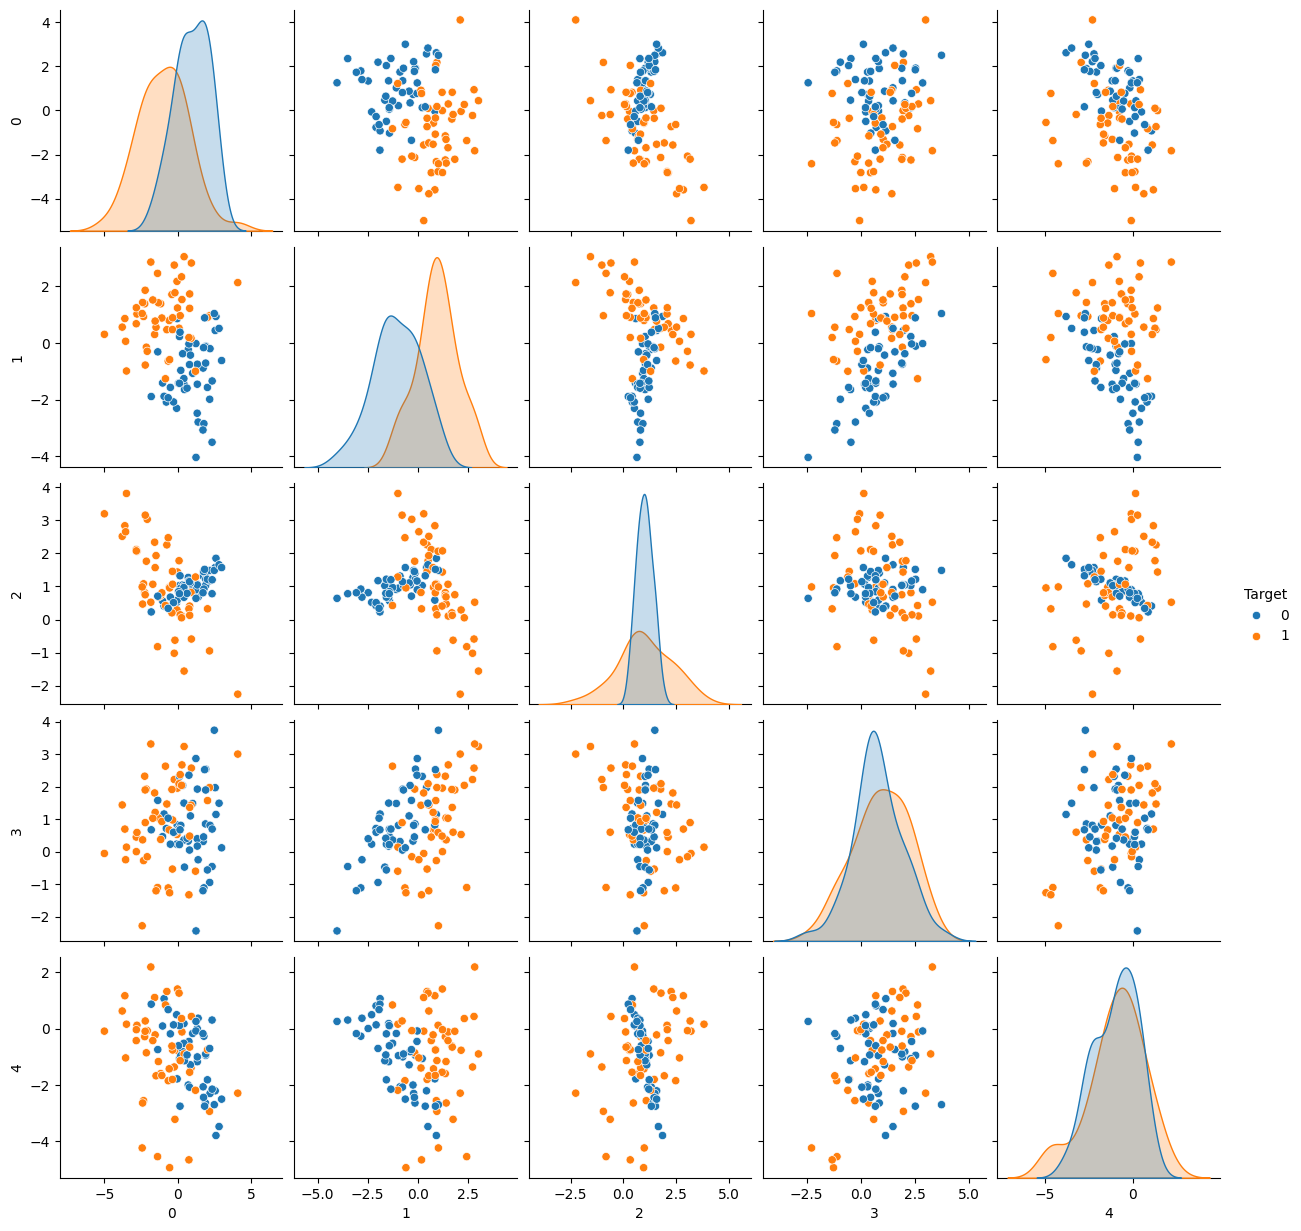

In [66]:
sns.pairplot(df,hue= 'Target')

<Axes: >

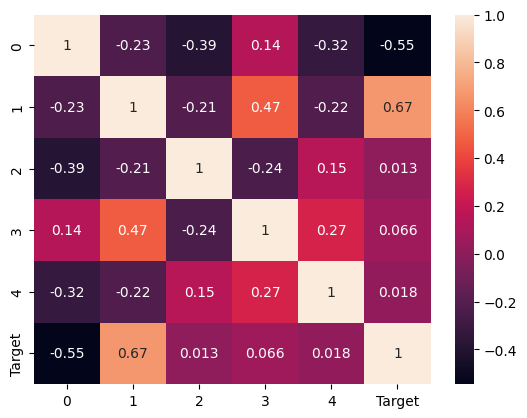

In [72]:
sns.heatmap(df.corr(), annot=True)

In [73]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,0.721639,-0.234684,1.270386,0.326454,-1.999443,0
1,1.736046,-0.884992,1.312359,0.313426,-2.063891,0
2,-0.069188,-2.302615,0.518803,0.232552,0.496017,0
3,1.330611,-2.476666,0.809955,0.397876,0.005731,0
4,-0.232444,2.743711,-1.018694,2.217627,-1.359930,1


In [74]:
bag = BaggingClassifier(max_features=2)

In [77]:
bag.fit(df.iloc[:,:5] ,df.iloc[:,-1])

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",10
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",2
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


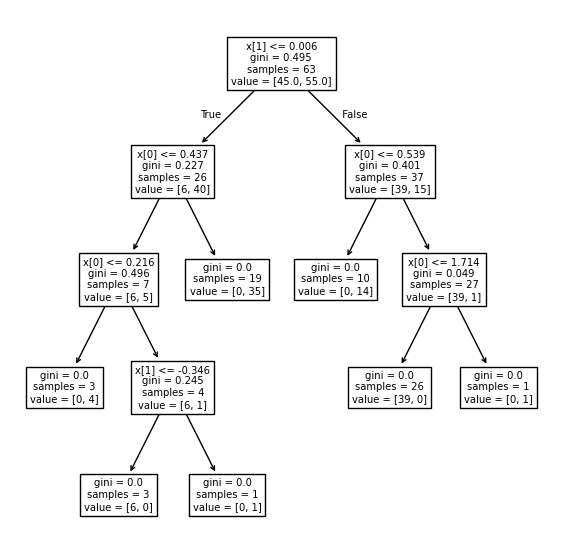

In [79]:
plt.figure(figsize=(7,7))
plot_tree(bag.estimators_[0])
plt.show()

##  Random Forest ko apply karunga ab 